# Clean CbCR data of the OECD
This Notebook builds a dataset with bilateral values for MNS's reveneus, tax payments, and employment. It corrects the following problems inherent in the OECD's CbCR data:

Load packages

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tjn_tools
from adjustText import adjust_text
from datetime import datetime
import statsmodels.formula.api as smf
from itertools import permutations, product
import pickle

Adjust settings

In [56]:
pd.options.mode.chained_assignment = None  # default='warn', supress warnings for chained assignments
sns.set(font_scale=1.2,style="whitegrid") # adjust settings for figures...
%matplotlib inline
pd.set_option('display.max_columns', 100)  # ...and tables

Set paths and define dataset names

In [57]:
path_files = "../../data/raw/estimations/" # path for raw data
path_files_final = "../../data/final/estimations/" # path for final datasets

# Input from .config_new file (and make sure Python is not using the cached file)
import importlib
import config_new
importlib.reload(config_new)
from config_new import CBCR_FILE, ORBIS_FILE, CORPORATE_TAX_RATE_PATH, YEAR_CBCR, UNILATERAL_CROSS, UNILATERAL_PANEL, BILATERAL_PANEL, GRAV_FILE, LINK_FILE
last_year_mean = YEAR_CBCR-6 

# Define output files
# Section 1
etr_output = f"{path_files_final}{YEAR_CBCR}_cbcr_etr_rates_new.xlsx"
cbcr_output = f"{path_files_final}{YEAR_CBCR}_cbcr_cleaned_dividends_new.xlsx"

# Section 2
df_pairs_output = f"{path_files_final}{YEAR_CBCR}_df_pairs_new.tsv"
df_fin_output = f"{path_files_final}{YEAR_CBCR}_df_fin_new.tsv"
d_groups2countries_output = f"{path_files_final}{YEAR_CBCR}_d_groups2countries_new.dump"
iso3_to_wages_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_wages_new.dump"
iso3_to_cit_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_cit_new.dump"
iso3_to_gdp_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_gdp_new.dump"
info_expenditures_output = f"{path_files_final}{YEAR_CBCR}_info_expenditures_new.csv"

Define country groups
 - Note: "Other America" and "Other Europe" usually contain many tax havens. Javier: "When split only by continent, remove across all countries" (what does that mean???)

In [58]:
# Secrecy jurisdictions
ofcs = {'MLT', 'BRB', 'BMU', 'CUW', 'CYP', 'HKG', 'PRI', 'SGP', 'IRL', 'MUS', 'VGB', 'CYM', 
              'LUX', 'JEY', 'IMN', 'NLD', 'GIB', 'CHE', 'BHS', 'GGY', 'MAC', 'HUN', 'ARE'}
# Country groups
groups = {"ASIAT","EUROP","AMER","AFRIC",'OTE','OAM',"OAF","OAS"}

Import and adjust corporate income tax rates

In [59]:
cit_file = CORPORATE_TAX_RATE_PATH 
iso3_to_cit  = pd.read_csv(cit_file)
iso3_to_cit = iso3_to_cit.loc[iso3_to_cit["year"]==YEAR_CBCR].groupby("country_iso3")["nctr_final"].mean()

iso3_to_cit["MLT"] *= 1/7 # adjust Malta's cit by the 6/7th rule 
iso3_to_cit["GIB"] = 0 # adjust Gibraltar's CIT as it only applies to resident income
iso3_to_cit["MCO"] = 0 # adjust MCO because ??
iso3_to_cit["AND"] = 0 # adjust because ??
iso3_to_cit["CAF"] = 0.3 # adjust because ??
iso3_to_cit["HTI"] = 0.3 # adjust because ??
iso3_to_cit["YEM"] = 0.2 # adjust because ??
iso3_to_cit["NCL"] = 0 # Adjust to zero as only NCL income is taxable
iso3_to_cit["PRK"] = 0.325 # adjust MCO because ??
iso3_to_cit["COD"] = 0.28 # adjust MCO because ??
iso3_to_cit["TLS"] = 0.10 # adjust MCO because ??
iso3_to_cit["USA"] = 0.27 # Include state level taxes for US

pickle.dump(iso3_to_cit,open(iso3_to_cit_output,"wb+")) # store CIT tax rates as dictionary
for iso3 in set(iso3_to_cit[np.isnan(iso3_to_cit)].index): # Print countries for which CIT is missing
    try:
        country_name = tjn_tools.iso3_to_name(iso3)
        print(iso3, country_name)
    except KeyError:
        print(iso3, "Unknown country")

EAZ Zanzibar
IOT British Indian Ocean Territory
GUF French Guiana
CCK Cocos Islands
NIU Niue
ATA Unknown country
CSK Czechoslovakia
MTQ Martinique
CUB Cuba
SOM Somalia
ATF French Southern Territories
ANT Netherlands Antilles
PCN Pitcairn
SJM Svalbard and Jan Mayen Islands
SUN Soviet Union
SPM St. Pierre and Miquelon
ESH Western Sahara
YUG Yugoslavia
GLP Guadeloupe
SGS South Georgia and the South Sandwich Islands
HMD Heard Island and McDonald Islands
MYT Mayotte
TUV Tuvalu
VAT Vatican
SCG Serbia and Montenegro
REU Reunion
CXR Christmas Island
TKL Tokelau
NFK Norfolk Island
BVT Bouvet Island
SHN Saint Helena
PUS Unknown country
MHL Marshall Islands


# 1. Clean CBCR data and calculate ETR
- Input file: CBCR (https://stats.oecd.org/Index.aspx?DataSetCode=CBCR_TABLEI). The file location and name is specified in the config file of this directory.
- Orbis with number of expected companies. The file location and name is specified in the config file of this directory.
    - Columns needed:
        - Country ISO code
        - Operating revenue
        - Number of employees
        - GUO code
    - Search strategy:
        - Status: Active companies, Unknown situation
        - Operating revenue (Turnover), using estimates (m USD): min=750, Last available year, exclusion of companies with no recent financial data and Public authorities/States/Governments
        - Ultimate Owners: Global; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - Shareholders with foreign subsidiaries: located anywhere (excluding unknown countries) not ultimately owned but at least 51% owned; May have other shareholder in the foreign country; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - NACE Rev. 2, core code (4 digits): Different from 65


Define relevant variables

In [60]:
fin_needed = ['Unrelated Party Revenues','Profit (Loss) before Income Tax', 'Adjusted Profit (Loss) before Income Tax',
       'Income Tax Paid (on Cash Basis)','Income Tax Accrued - Current Year','Number of Employees',
       'Tangible Assets other than Cash and Cash Equivalents','Number of CbCRs','Number of CbCR Sub Groups','Number of Entities']

Specify function that calculates ETRs

In [61]:
def calculate_etr(df):
    d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
    d["etr"] = d["Income Tax Paid (on Cash Basis)"]/d["Profit (Loss) before Income Tax"]
    return d["etr"]

def main_etrs(year,file,g="Sub-Groups with positive profits"):
    if isinstance(file,str):
        df = pd.read_csv(file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
        df = df.loc[df["Grouping"]==g]
        df = df.loc[df["Variable"].isin(fin_needed)]
        df = df.loc[df["Year"]==year]
        df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
    else:
        df = file
    df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])

    df_for = df.loc[df["COU"] != df["JUR"]]
    df_dom = df.loc[df["COU"] == df["JUR"]]
    df_tot = df

    df_etr = pd.concat([calculate_etr(df_for),
                       calculate_etr(df_dom),
                       calculate_etr(df_tot)],
                      axis=1)
    df_etr.columns = ["ETR_foreign","ETR_domestic","ETR_total"]
    return df_etr

## 1.1 CBCR vs Orbis: Compare coverage

1.1.1 Coverage of OECD's CBCR files

In [62]:
total_cov = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"]) # select relevant column
total_cov = total_cov.loc[total_cov["Year"]==YEAR_CBCR] # only take rows of relevant years
total_cov = total_cov.loc[total_cov["Grouping"]=="All Sub-Groups"] # take all firms (no matter if profitable or not)
total_cov = total_cov.loc[total_cov["Variable"]=="Number of CbCRs"] # select relevant variable: number of CbCrs
total_cov = total_cov.loc[(total_cov["JUR"] == "FJT") | (total_cov["JUR"] == total_cov["COU"])] # to get number of reporting companies: take maximum of CbCRs in home countries or aggregated CbCRs abroad
total_cov = total_cov.groupby(["COU"]).max()["Value"]

1.1.2 Coverage of Orbis Ownership data
- Number of Global Ultimate Owners (GUOs)

In [63]:
cs = pd.read_excel(ORBIS_FILE,na_values=["n.a."],keep_default_na=False) # import Orbis GUOs
cs = cs.dropna(subset=["GUO - BvD ID number"]) # drop observations that do not have a BvD ID
cs = cs.loc[cs["Country ISO code"]==cs["GUO - BvD ID number"].str[:2]] # keep only rows where BvD ID starts with ISO Code of country (row of home country)
cs["max_turnover"] = cs.groupby(["GUO - BvD ID number"])["Operating revenue (Turnover)\nth USD Last avail. yr"].transform(max) # calculate highest turnover per GUO to delete duplicates later
cs = cs.loc[cs["Operating revenue (Turnover)\nth USD Last avail. yr"]==cs["max_turnover"]] # only keep GUO with highest turnover
cs = cs.drop_duplicates(subset=["GUO - BvD ID number"]) # if highest turnover is duplicate, drop
cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])& \
         (cs["GUO - BvD ID number"].str[:2]!="WW"),"Country ISO code"] \
       = cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])& \
         (cs["GUO - BvD ID number"].str[:2]!="WW"),"GUO - BvD ID number"].str[:2] # when the country iso3 code differs from the GUO's iso3, we use the GUO's iso3
cs = cs.groupby("Country ISO code").agg({"GUO - BvD ID number": len,"Operating revenue (Turnover)\nth USD Last avail. yr":np.sum,"Number of employees\nLast avail. yr":np.sum}).reset_index()
cs.columns = ["country","Reporting companies in Orbis","Turnover Orbis","Emp Orbis"] # Rename columns to produce understandable table
cs["Turnover Orbis"] *= 1000 # report turnover in USD
cs["country"] = cs["country"].map(tjn_tools.get_iso3) # replace country by ISO3
cs = cs.dropna(subset=["country"]) # drop if no country info is provided, ie if no ISO3 was assigned

II not matched to any file


1.1.3 Compare CBCR coverage to Orbis coverage

Plot for CbCR coverage

54.0

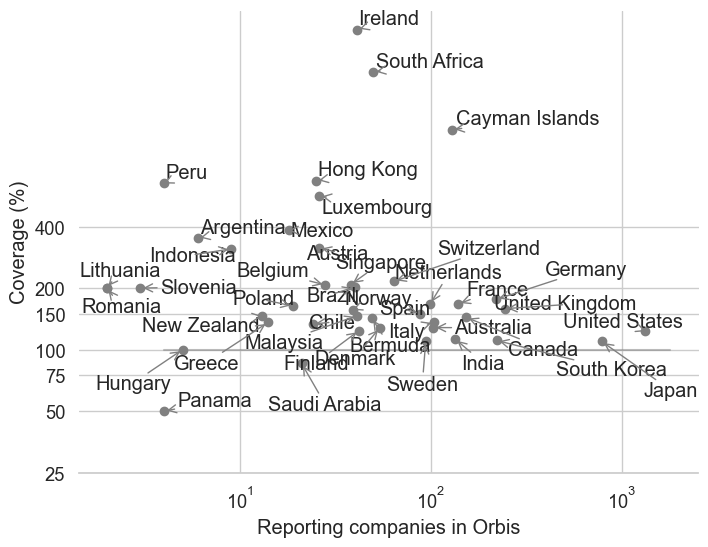

In [64]:
potential_countries = cs.loc[cs["Reporting companies in Orbis"]>=3,"country"].values # define potential countries as all that have at least 3 GUOs in Orbis
cs = pd.concat([cs.set_index("country"),total_cov],axis=1) # combine Orbis and CbCR data
cs.rename(columns={'Value': 'Filed CbCRs'}, inplace=True)
cs["Coverage"] = np.log2(cs["Filed CbCRs"]/cs["Reporting companies in Orbis"]) # Log 2 of fraction of companies in CbCR data, compared to Orbis GUOs (WHY LOG 2???)
cs_plot = cs.dropna() # drop NAs for plot
plt.figure(figsize=(8,6))
plt.plot(cs_plot["Reporting companies in Orbis"],cs_plot["Coverage"],"o",color="grey")
texts = []
for c,x,y in zip(cs_plot.index,cs_plot["Reporting companies in Orbis"],cs_plot["Coverage"]):
    texts.append(plt.text(x,y,tjn_tools.iso3_to_name(c)))
plt.plot([4,1800],[0,0],alpha=0.5,color="grey")             
plt.xscale("log")
adjust_text(texts,cs_plot["Reporting companies in Orbis"].values, cs_plot["Coverage"].values, 
            arrowprops=dict(arrowstyle='->', color='grey'))
bins = np.array([0.25,0.5,0.75,1,1.5,2,4])
coverage = np.log2(bins)
plt.yticks(coverage,np.array(100*bins,dtype=int))
plt.xlabel("Reporting companies in Orbis")
plt.ylabel("Coverage (%)")
sns.despine(bottom=False,left=True)
expected_companies = cs["Reporting companies in Orbis"]
expected_companies = expected_companies.to_dict()
expected_companies["DNK"]

Table for CbCR coverage

In [65]:
cs_plot["Ratio"] = cs_plot["Reporting companies in Orbis"]/cs_plot["Filed CbCRs"]
x = cs_plot[["Reporting companies in Orbis","Filed CbCRs","Ratio"]].sort_values(by="Ratio", ascending=False)
x.index = x.index.map(tjn_tools.iso3_to_name)
x["Reporting companies in Orbis"] = x["Reporting companies in Orbis"].astype(int)
x["Filed CbCRs"] = x["Filed CbCRs"].astype(int)
x["Ratio"] = x["Ratio"].round(2)
x

,Reporting companies in Orbis,Filed CbCRs,Ratio
Panama,185,2,92.81
Hungary,204,5,40.82
Lithuania,128,4,32.05
Romania,128,4,32.05
Slovenia,161,6,26.96
Saudi Arabia,323,18,17.95
Greece,289,19,15.23
New Zealand,283,19,14.91
Chile,334,32,10.44
Argentina,219,21,10.44


1.1.4 Number of available countries and reported jurisdictions

Table 1.1. in methodology paper? Or what is the following code for???

In [66]:
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Year"]==YEAR_CBCR]
df = df.loc[df["Variable"].isin(fin_needed)]
df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9
df

Variable,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
0,ARG,ARG,Argentina,NaN,1.234151e+09,7.262580e+08,21.0,21.0,159354.0,266.0,1.739470e+10,9.545845e+10,6.026053e+10
1,ARG,AUS,Australia,NaN,0.000000e+00,0.000000e+00,2.0,2.0,1.0,2.0,6.242739e+06,4.296447e+05,6.582965e+06
2,ARG,BOL,Bolivia,NaN,9.154420e+05,1.106431e+06,7.0,7.0,154.0,11.0,1.628879e+06,7.660177e+07,1.180915e+08
3,ARG,BRA,Brazil,NaN,1.291971e+07,2.017510e+07,13.0,13.0,5868.0,29.0,1.586243e+08,8.925710e+08,9.337754e+08
4,ARG,CHL,Chile,NaN,9.098176e+06,-1.644266e+05,8.0,8.0,2221.0,13.0,-1.002867e+09,2.179786e+09,1.943392e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAF,UGA,Uganda,NaN,2.815546e+07,2.133520e+07,13.0,13.0,4101.0,42.0,1.027182e+08,1.166402e+08,3.969058e+08
2561,ZAF,USA,United States,NaN,-2.780758e+08,-1.952776e+07,31.0,31.0,18994.0,169.0,-1.277203e+09,1.815746e+10,8.989841e+09
2562,ZAF,ZAF,South Africa,NaN,3.771342e+09,3.271322e+10,58.0,58.0,1005499.0,3700.0,2.989862e+10,1.311272e+11,1.365236e+11
2563,ZAF,ZMB,Zambia,NaN,4.691055e+07,5.414162e+07,42.0,42.0,12584.0,98.0,8.937492e+07,4.986565e+08,1.409090e+09


Table 1.2 in methodology paper

In [67]:
df = pd.read_csv(CBCR_FILE)
df = df.loc[df["Year"]==YEAR_CBCR]
df1 = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
a = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

df1 = df.loc[df["Grouping"]=="All Sub-Groups"]
b = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

pd.concat([b,a],axis=1).transpose().fillna(0).astype(int)

COU,CHE,DEU,CYM,USA,ROU,JPN,PER,ESP,HKG,DNK,ITA,BMU,IND,FRA,LUX,AUS,MEX,NOR,SAU,IDN,ZAF,BRA,PAN,SGP,MYS,ARG,BEL,LVA,CAN,NLD,CHL,SVN,SWE,GBR,LTU,POL,AUT,GRC,IMN,KOR,NZL,HUN,FIN,IRL,CZE
count,169,164,150,147,147,140,129,121,120,116,108,104,95,94,91,83,75,65,61,46,41,40,35,35,29,24,21,16,15,10,10,7,7,7,7,6,6,6,6,2,2,2,2,2,2
count,166,163,124,101,133,118,112,80,94,119,81,77,94,33,90,42,63,49,41,34,35,31,0,42,23,19,21,0,15,29,10,6,7,6,6,0,6,6,6,2,2,0,2,2,0


No clue what the following code should serve for

In [68]:
#Make sure the cleaning in 2016  (multiplying everything by 2 in china) was mostly okay
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
# df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Variable"].isin(fin_needed+['Number of CbCRs'])]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
# df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9
df.loc[(df["JUR"]=="COD")]


Variable,Year,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
853,2016,ZAF,COD,Democratic Republic of the Congo,NaN,4.379733e+06,5.813607e+06,4.0,4.0,177.0,7.0,55954533.0,4.693023e+07,1.019855e+08
1287,2017,CHN,COD,Democratic Republic of the Congo,NaN,1.869742e+07,1.155755e+07,7.0,7.0,4057.0,19.0,68889224.0,6.037538e+08,1.684346e+08
2043,2017,JPN,COD,Democratic Republic of the Congo,NaN,1.052030e+06,5.057420e+05,1.0,1.0,234.0,2.0,3795278.0,2.943714e+07,6.015086e+07
2573,2017,ZAF,COD,Democratic Republic of the Congo,NaN,3.601608e+06,1.790003e+06,2.0,2.0,149.0,2.0,10299477.0,3.474348e+07,7.490633e+07
2909,2018,CHE,COD,Democratic Republic of the Congo,NaN,NaN,NaN,2.0,2.0,NaN,7.0,NaN,NaN,NaN
3205,2018,DEU,COD,Democratic Republic of the Congo,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4401,2018,ROU,COD,Democratic Republic of the Congo,NaN,6.314050e+05,5.354520e+05,1.0,1.0,66.0,1.0,6330187.0,6.029443e+07,4.829127e+07


## 1.2 Read and clean CBCR
- Data limitations: https://www.oecd.org/tax/tax-policy/anonymised-and-aggregated-cbcr-statistics-disclaimer.pdf
- Report: https://www.oecd.org/tax/tax-policy/corporate-tax-statistics-database.htm


- Data on the United States --> Cleaned in the paper with Zucman
    - US domestic: 55%
    - US foreign: 7% (https://gabriel-zucman.eu/files/GBJZ2021.pdf) !!! Shouldn't this be 39% as the paper finds for 2018

- Other countries: correct using notes when possible:
    - Ireland: https://www.oecd.org/tax/tax-policy/ireland-cbcr-country-specific-analysis.pdf
        --> No issues found
    - Italy: https://www.oecd.org/tax/tax-policy/italy-cbcr-country-specific-analysis.pdf
        -->  The average value of the share of dividends is instead equal to 38.2%, thus implying that dividends are concentrated in few firms.  
    - Netherlands: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> 5794 out of 36802 = 15.74%
    - United Kingdom: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> UK reported profit.: The total value of dividends extracted for groups we believe had included intragroup dividends received was approximately £55 billion. (78.169865 out of 152.918884 = 51.1%) 	)
    - Sweden: https://www.oecd.org/tax/tax-policy/sweden-cbcr-country-specific-analysis.pdf
        --> Dividends share 51.95%


Correct for dividends, but not for participation results (de-mergers, takeovers and disposal typically involve tax avoidance strategies in tax havens.) 


Cleaning strategy based on the analysis below:
- Profit and coordination centers:
    - Domestic: Analysis done for those countries (except Belgium and LUX)
        - Belgium: 50% (same as uk/swe)
        - LUX: Nothing (tax rates are usually around there)
    - Foreign : 
        -Remove 10% (a bit more than what we find in the US for that year (9% = 42 double counting/454 tax havens))
- USA:
    - Domestic: 
        - Remove 35%
    - Foreign: 
        - No correction


- Other countries:
    - Domestic:
        - If domestic etr << foreign etr (10 points): Correct as in ita (35%)
    - Foreign: 
        - No correction

- Groups:
    - Domestic:
        - N/A
    - Foreign:
        - Remove 5% (10% from tax havens, with 50% of profits in tax havens)


Text(0, 0.5, 'ETR (Foreign MNCs)')

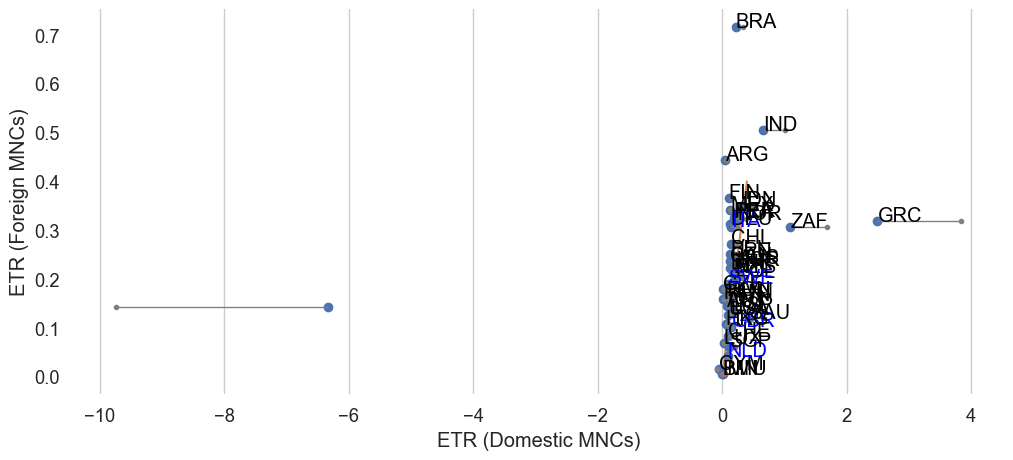

In [69]:
#Check out cleaning. USe all groups to get a most comparable picture
df_etrs = main_etrs(year=YEAR_CBCR,file=CBCR_FILE,g="All Sub-Groups")
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs

plt.figure(figsize=(12,5))
for i,row in df_etrs.iterrows():
    if row["ETR_domestic"]>-0.2:
        if i in ["NLD","GBR","ITA","SWE"]:
            color = "blue"
        else:
            color = "black"
        plt.annotate(i,(row["ETR_domestic"],row["ETR_foreign"]),color=color)
plt.plot(df_etrs["ETR_domestic"],df_etrs["ETR_foreign"],"o")


def plot_c(cs,color="tomato"):
    c,fraction = cs
    plt.plot(df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_foreign"],".",color=color)
    plt.plot([df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_domestic"]],[df_etrs.loc[c,"ETR_foreign"],df_etrs.loc[c,"ETR_foreign"]],lw=1,color=color)

d_reduction = dict()
for c in df_etrs.dropna(subset=["ETR_domestic"]).index:
    d = dict([("SWE",0.52),("ITA",0.38),("USA",0.35)]) #2017
#     d = dict([("SWE",0.52),("ITA",0.38)]) #2016
    
    if c in ["BEL","SGP","IMN","BMU"]: 
        plot_c((c,0.5),color="red")
        frac = 0.5
    elif c in ["SVN","MEX"]: #2017
#     elif c in ["SVN","USA","CHN","MEX"]: #2016
        frac = 0
    elif c in d:
        plot_c((c,d[c]),color="cornflowerblue")
        frac = d[c]
    elif c in ("GBR","NLD"): #2017
#     elif c in []: #2016
        frac = 0 #They report their figure of adjusted profits
    elif c == "LUX": #negative profits
        frac = 0
    else:
        frac = 0.35
    d_reduction[c] = frac
    plot_c((c,frac),color="gray")
        
plt.plot([0,0.4],[0,0.4],zorder=0)
plt.grid(axis="y")
sns.despine(left=True,bottom=True)
plt.xlabel("ETR (Domestic MNCs)")
plt.ylabel("ETR (Foreign MNCs)")
# plt.plot([0,0.4],[0.05,0.45])

In [70]:
# Manually adjust countries without domestic ETRs for "sub-groups with positive profits". Use all sub-groups in this case
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Year"]==YEAR_CBCR]
missing_c = (set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="All Sub-Groups"),"COU"]) -
         set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="Sub-Groups with positive profits"),"COU"]))
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
#Calculate etr
display(main_etrs(YEAR_CBCR,df.loc[(df["JUR"].isin(missing_c))]))

#Manually adjust
d_reduction["AUT"] = 0.35 #2017 only, much lower etr domestic
d_reduction["LVA"] = 0 #2017 only, higher for etr domestic
d_reduction["POL"] = 0.35 #2016 and 2017much lower etr domestic

,ETR_foreign,ETR_domestic,ETR_total
JUR,,,
CZE,0.179995,0.015819,0.120534
HUN,0.157314,0.081806,0.131900
LVA,0.131024,0.143152,0.138714
PAN,0.160156,0.021509,0.072373
POL,0.203071,0.207982,0.204921


In [71]:
#Clean data CBCR
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Variable"].isin(fin_needed)]
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Year"]==YEAR_CBCR]
df = pd.pivot_table(df,index=["Grouping","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])


#Countries with analysis
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    print("Cleaning countries with corrected data: NLD and GBR")
    display(df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"])])
    df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Profit (Loss) before Income Tax"] = df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Adjusted Profit (Loss) before Income Tax"]

print("Cleaning countries with analysis: ITA, SWE, BEL, USA")
df["Reduction"] = df["COU"].map(d_reduction).fillna(0)

filter_ = (df["COU"]==df["JUR"])&(df["Profit (Loss) before Income Tax"]>0)

d1 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-df.loc[filter_,"Reduction"])
d2 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
d = pd.concat([d1,d2],axis=1).reset_index()
display(d.loc[d["Grouping"]=="All Sub-Groups"])

print("Cleaning foreign activities in tax havens")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(ofcs))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.1)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)

print("Cleaning foreign activities in groups")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(groups | {"FJT"}))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.05)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)


df.to_excel(cbcr_output)

Cleaning countries with corrected data: NLD and GBR


Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
1126,All Sub-Groups,GBR,GBR,United Kingdom,1.750596e+10,1.171499e+10,1.007553e+10,387.0,387.0,3164742.0,21717.0,6.680190e+10,8.524017e+11,9.894753e+11
1878,All Sub-Groups,NLD,NLD,Netherlands,2.177767e+10,4.934474e+09,4.238728e+09,165.0,165.0,582272.0,6647.0,4.613006e+10,1.246143e+11,3.088054e+11
4022,Sub-Groups with negative profits,NLD,NLD,Netherlands,-4.440012e+09,-1.781823e+08,3.130935e+08,48.0,48.0,76442.0,1132.0,-4.714633e+09,2.379649e+10,2.786139e+10
5215,Sub-Groups with positive profits,GBR,GBR,United Kingdom,8.027598e+10,1.003663e+10,8.049864e+09,259.0,259.0,2458346.0,14579.0,1.295719e+11,6.833192e+11,7.611233e+11
5852,Sub-Groups with positive profits,NLD,NLD,Netherlands,2.621768e+10,5.112656e+09,3.925635e+09,117.0,117.0,505830.0,5515.0,5.084469e+10,1.008178e+11,2.809440e+11


Cleaning countries with analysis: ITA, SWE, BEL, USA


,COU,Grouping,Profit (Loss) before Income Tax,Profit (Loss) before Income Tax
0,ARG,All Sub-Groups,17.394704,11.306557
2,AUS,All Sub-Groups,89.433549,58.131807
4,AUT,All Sub-Groups,17.260176,11.219115
6,BEL,All Sub-Groups,18.109300,9.054650
8,BMU,All Sub-Groups,5.202382,2.601191
10,BRA,All Sub-Groups,57.436841,37.333946
12,CAN,All Sub-Groups,147.456309,95.846601
14,CHE,All Sub-Groups,57.563629,37.416359
16,CHL,All Sub-Groups,13.374077,8.693150
19,CZE,All Sub-Groups,6.794214,4.416239


Cleaning foreign activities in tax havens
1942.7005628621928
1748.4305065759738
Cleaning foreign activities in groups
7644.687948908701
7262.453551463266


In [72]:
# df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df.loc[(df["COU"]=="CHN")].sort_values(by="Profit (Loss) before Income Tax").tail(10)

Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues,Reduction


In [73]:
df_etrs = main_etrs(year=YEAR_CBCR,file=df.loc[df["Grouping"]=="Sub-Groups with positive profits"])
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"ETR_foreign"] = df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"cit"]
df_etrs.loc[df_etrs["ETR_total"]>0.6,"ETR_total"] = df_etrs.loc[df_etrs["ETR_total"]>0.6,"cit"]
df_etrs.to_excel(etr_output)
df_etrs.loc["AUT"]

ETR_foreign     0.116317
ETR_domestic    0.090339
ETR_total       0.105574
cit             0.250000
Name: AUT, dtype: float64

Text(0.5, 1.0, '(B) Corrected for double counting')

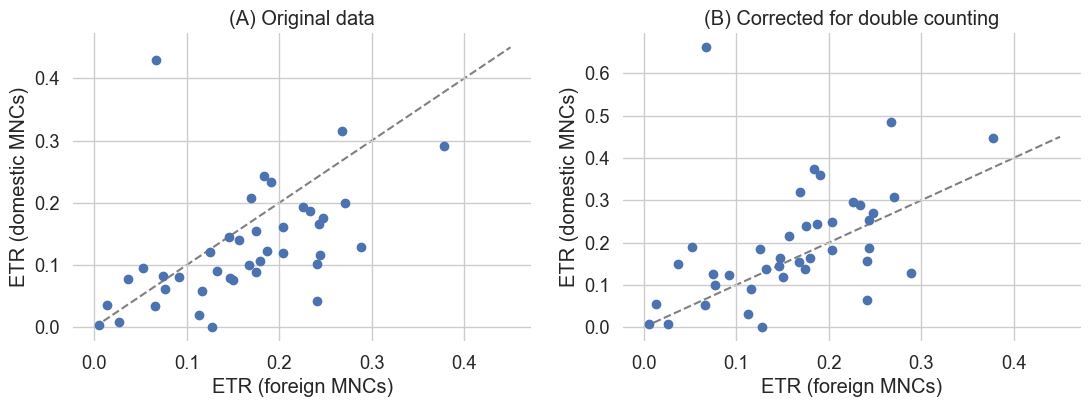

In [74]:
df_etrs2 = main_etrs(year=YEAR_CBCR,file=CBCR_FILE,g="Sub-Groups with positive profits")
d = pd.concat([df_etrs, df_etrs2],axis=1)
d.columns = ["f1","d1","t1","cit","f2","d2","t2"]

def plot_etr_robustness(d,v2):
    plt.plot(d["f1"],d[v2],"o")
    plt.plot([0,0.45],[0,0.45],"--",color="gray",zorder=0)
    plt.xlabel("ETR (foreign MNCs)")
    plt.ylabel("ETR (domestic MNCs)")
    sns.despine(bottom=True,left=True)
    
plt.figure(figsize=(13,4))
plt.subplot(121)
plot_etr_robustness(d,"d2")
plt.title("(A) Original data")

plt.subplot(122)
plot_etr_robustness(d,"d1")
plt.title("(B) Corrected for double counting")

In [75]:
#Fix code for kosovo
df["COU"] = df["COU"].replace({"XKV": "XKX"})
df["JUR"] = df["JUR"].replace({"XKV": "XKX"})

In [76]:
# df_fin.loc[df_fin["iso3_o"]=="USA"].sort_values(by="pi",ascending=False)

## 2. Create other variables to train the model

### 2.1. Financial information

In [77]:
#Financial variables
df_fin = df.loc[df["Grouping"]=="All Sub-Groups",["COU","JUR","Number of Employees","Profit (Loss) before Income Tax","Income Tax Paid (on Cash Basis)","Unrelated Party Revenues","Tangible Assets other than Cash and Cash Equivalents"]]
df_fin.columns = ["iso3_o","iso3_d","emp","pi","txc","revt","t_at"]
df_fin["iso3_d"] = df_fin["iso3_d"].replace("ANT","CUW")


In [78]:
## Countries to include
countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(tjn_tools.get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset

FJT not matched to any file
OAF not matched to any file
OAM not matched to any file
OAS not matched to any file
OTE not matched to any file
STA not matched to any file
AFRIC not matched to any file
AMER not matched to any file
ASIAT not matched to any file
EUROP not matched to any file
GRPS not matched to any file


C:\Users\AlisonSchultz\AppData\Local\Temp\ipykernel_21760\1014446749.py:2: DeprecationWarning: This method is going to be deprecated use name_to_iso3 and iso3_to_iso2 instead.
  countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(tjn_tools.get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset


### 2.2 Import and generate additional relevant variables

2.2.1 Import country-level variables and construct additional variables

In [79]:
## Import geographic information and FSI & CTHI
region = pd.read_csv(UNILATERAL_CROSS,usecols=["iso3","region_tjn","region","ukt","oecd","oecd_oct","eu28","g20",
                                                               "fsi_2022_rank","fsi_2022_score","cthi_2021_rank","cthi_2021_share","cthi_2021_score"])

## Import other variables needed
usecols = ["iso3","year","gdp","population","physicians_per_1000","nurses_per_1000","greenfieldfdi_inward","greenfieldfdi_outward",
          "resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","health_exp_gdp","govt_exp_educ_gdp",
          "fdi_inflows_wdi","external_debt_stocks","ip_payments","ip_receipts","who_gvt_health_expenditure","month_wage",
          "new_businesses_registered","imports","exports","gdp_pc","gdp_deflator","govt_exp_gdp"]
other_info = pd.read_csv(UNILATERAL_PANEL,usecols=usecols)

#Fill GDP, population, nurses, and physicians with info from previous/earlier years
for i in ["gdp","population","physicians_per_1000","nurses_per_1000"]:
    other_info[i] = other_info.groupby('iso3')[i].bfill(limit=3)
    other_info[i] = other_info.groupby('iso3')[i].ffill(limit=3)

# Only keep average of the last 5 years
# DOES THIS MAKE SENSE???
other_info = other_info.loc[other_info["year"]>last_year_mean].groupby("iso3").mean().reset_index()

# Merge geographic and other information
other_info = pd.merge(other_info,region,how="outer")

# Calculate total number of physicians and nurses
other_info["physicians"] = other_info["physicians_per_1000"]*other_info["population"]/1000
other_info["nurses"] = other_info["nurses_per_1000"]*other_info["population"]/1000

# Convert expenditures (which are measured as % of GDP) to USD
for i in ['who_gvt_health_expenditure',"resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","health_exp_gdp","govt_exp_educ_gdp","govt_exp_gdp"]:
    other_info[i] = other_info[i]*other_info["gdp"]
    
# Calculate resource revenue as fraction of GDP
other_info["resource_revenue_gdp"] = other_info["resource_revenue"]/other_info["gdp"]

# Covert variables given in % to fractions
other_info["govt_exp_educ_gdp"] /= 100
other_info["health_exp_gdp"] /= 100

# add corporate income tax rate to dataset
other_info["cit"] = other_info["iso3"].map(iso3_to_cit)

2.2.2 Clean wage variable
- Javier has removed the wage variable when the wage was too high/too low in comparison to GDP. 
- I am not sure if we want to follow this approach as I think that the  "mismatch" might be linked to profit shifting variables or just a sign that profit is shifted. For instance, Cyprus wages are lower than "expected", but this could be the case because Cyprus' GDP is inflated by activities related to profit shifting. If we systematically remove observations linked to high profit shifting (in or out), this might bias our results without need.

BDI 19.75889388706852 226.51 2.4391853806810215
BRN 2681.35456973835 1420.16 0.6355525619802734
DOM 622.4961328702933 306.9942857142857 0.7069082819575578
HKG 3784.3363998253935 1766.34 0.7619609386938849
IDN 320.76218430233575 143.32000000000002 0.80562009725048
LKA 339.1694587221519 179.35999999999999 0.6371049013955319
MEX 822.2173152963087 346.8633333333333 0.8630738836539243
QAT 5653.903707329012 2973.6625 0.6425518701586761
                            OLS Regression Results                            
Dep. Variable:     np.log(month_wage)   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     801.6
Date:                Tue, 04 Jul 2023   Prob (F-statistic):           5.10e-72
Time:                        06:58:01   Log-Likelihood:                -30.586
No. Observations:                 128   AIC:                             67.17
Df Residuals:

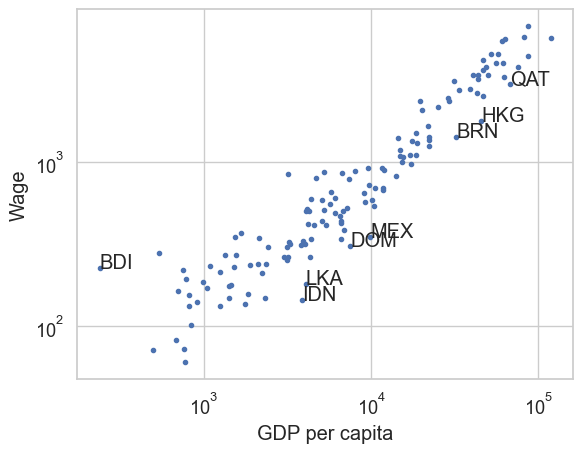

In [80]:
# Identify implausible values
remove = [] # Create list of observations to be removed due to implausible values
for i,x,y in zip(other_info["iso3"],other_info["gdp"]/other_info["population"],other_info["month_wage"]): # Detect implausible values for monthly wages
    if (np.log(x/12/y)>np.log2(1.5)) or (np.log(x/12/y)<-2): # rule of thumb which values are plausible (and which not)
        print(i,x/12,y,np.abs(np.log(x/12/y)))
        plt.annotate(i,(x,y))
        remove.append(i)
plt.plot(other_info["gdp"]/other_info["population"],other_info["month_wage"],".") # Plot relationship between GDP/capita and wages
plt.xscale("log")
plt.yscale("log")
plt.xlabel("GDP per capita")
plt.ylabel("Wage")
# remove implausible values and substitue missing values
other_info.loc[other_info["iso3"].isin(remove),"month_wage"] = np.nan # Delete observations where wage variable deviates too much from what we'd expect from GDP per capita
mod = smf.ols(formula='np.log(month_wage) ~ np.log(gdp) + np.log(population)', data=other_info) # Predict wage based on GDP and population to substitute missing or implausible values
res = mod.fit()
print(res.summary())
other_info["pred_month_wage"] = np.exp(res.predict(other_info)) # Include predicted wages in dataset
other_info.loc[np.isnan(other_info["month_wage"]),"month_wage"] = other_info.loc[np.isnan(other_info["month_wage"]),"pred_month_wage"] # substitute wages with predicted wages if wages are missing
del other_info["pred_month_wage"] # delete predicted wages
other_info.loc[other_info["iso3"]=="USA","month_wage"] =  4400 #Fix values for US according to https://www.bls.gov/news.release/pdf/wkyeng.pdf
other_info.loc[other_info["iso3"]=="AUS","month_wage"] =  4911 #Fix values for Australia according to https://www.abs.gov.au/statistics/labour/earnings-and-work-hours/average-weekly-earnings-australia/latest-release

2.2.3 Check and export dataset and parts of it

In [81]:
# Check dataset
duplicates = other_info[other_info.duplicated()]
print(duplicates)
other_info.sample(10)
# Export dataset
other_info.to_csv(info_expenditures_output, sep="\t", index=None)
# Export country's GDP to dictionary
iso3_to_gdp = other_info.set_index("iso3")["gdp"].dropna().to_dict()
pickle.dump(iso3_to_gdp,open(iso3_to_gdp_output,"wb+"))

Empty DataFrame
Columns: [iso3, year, resource_revenue, resource_taxes, total_taxes_revenue, cit_revenue, greenfieldfdi_outward, greenfieldfdi_inward, ip_payments, ip_receipts, fdi_inflows_wdi, external_debt_stocks, new_businesses_registered, imports, exports, gdp_pc, gdp_deflator, govt_exp_gdp, govt_exp_educ_gdp, physicians_per_1000, nurses_per_1000, health_exp_gdp, population, month_wage, who_gvt_health_expenditure, gdp, cthi_2021_rank, cthi_2021_share, cthi_2021_score, fsi_2022_rank, fsi_2022_score, region, region_tjn, eu28, oecd, g20, ukt, oecd_oct, physicians, nurses, resource_revenue_gdp, cit]
Index: []


In [82]:
a = pd.read_csv(UNILATERAL_PANEL,skiprows=1,sep="\t",nrows=1).columns
[_ for _ in a if "govt_ex" in _.lower()]

[]

In [83]:
#Other info
df_region = other_info.drop(columns=["year"])
df_region = df_region.rename(columns={"iso3":"iso3_d"})
df_region = df_region.drop_duplicates(subset=["iso3_d"]).dropna(subset=["iso3_d"])
iso3_to_region = df_region.set_index("iso3_d")["region_tjn"]

In [84]:
iso3_to_wages = other_info.set_index("iso3")["month_wage"].dropna().to_dict()
pickle.dump(iso3_to_wages,open(iso3_to_wages_output,"wb+"))


In [85]:
other_info.set_index("iso3")["month_wage"]

iso3
ABW    2196.767583
AFG      80.612954
AGO     295.397197
AIA            NaN
ALA            NaN
          ...     
XXK            NaN
YEM     136.425873
ZAF     848.670000
ZMB     269.010000
ZWE     197.343209
Name: month_wage, Length: 254, dtype: float64

## 2.3 Gravity dataset

In [86]:
def add_eq(df_dist,list_c,eq):
    """copies the data of another country"""
    for c in list_c:
        x = df_dist.loc[df_dist["iso3_o"]==eq]
        x["iso3_o"] = c
        df_dist = pd.concat([df_dist,x])
        x = df_dist.loc[df_dist["iso3_d"]==eq]
        x["iso3_d"] = c
        df_dist = pd.concat([df_dist,x])
    return df_dist

In [87]:
# Read gravity variables
df_dist = pd.read_stata(GRAV_FILE) # import gravity dataset
variables_to_import = list(filter(lambda x: x.startswith("dist"), df_dist.columns)) # only keep dist variables
variables_to_import.extend(["iso3_o", "iso3_d","year"]) #... and iso3_o, iso3_d and year
df_dist = df_dist.loc[:, variables_to_import]
df_dist = df_dist.loc[df_dist["year"]>last_year_mean].groupby(["iso3_o","iso3_d"]).mean().reset_index()

df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ROM","ROU")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ROM","ROU")
df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("TLS","TMP")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("TLS","TMP")
# df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ANT","CUW")
# df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ANT","CUW")
df_dist = df_dist.loc[(df_dist["iso3_o"]!="ANT")&(df_dist["iso3_d"]!="ANT")]

df_dist = add_eq(df_dist,["JEY","IMN","GGY"],"GBR")
# df_dist = add_eq(df_dist,["SRB","MNE"],"ALB")
# df_dist = add_eq(df_dist,["MCO"],"AND")
# df_dist = add_eq(df_dist,["SSD"],"SDN")
# df_dist = add_eq(df_dist,["COD"],"COG")
df_dist = add_eq(df_dist,["TLS"],"COG")

In [88]:
df_dist["iso3_d"].value_counts().head(5) #make sure there are no duplicates

iso3_d
ABW    251
PHL    251
NGA    251
NIC    251
NIU    251
Name: count, dtype: int64

In [89]:
set(df_fin["iso3_d"]) - set(df_dist["iso3_o"])

{'AFRIC',
 'AMER',
 'ASIAT',
 'EUROP',
 'FJT',
 'GRPS',
 'MAF',
 'OAF',
 'OAM',
 'OAS',
 'OTE',
 'STA',
 'VIR',
 'XKX'}

In [90]:
for i in set(df_fin["iso3_d"]) - set(df_dist["iso3_o"]):
    try:
        iso3_to_name(i)
    except:
        print(i)

VIR
OTE
ASIAT
MAF
OAM
EUROP
AFRIC
FJT
GRPS
STA
AMER
OAF
OAS
XKX


## 2.4 Variables from Linkedin

In [91]:
# Linkedin variables
df_link = pd.read_csv(LINK_FILE,sep="\t",index_col=0,na_values=[""],keep_default_na=False)
df_link["iso3_d"] = df_link["index"].map(tjn_tools.get_iso3)
df_link = df_link.drop(columns=["index","country","ln_pi"])
df_link = df_link.drop_duplicates(subset=["iso3_d"])

## 2.5 Bilateral info

In [92]:
df_bil = pd.read_csv(BILATERAL_PANEL)
df_bil = df_bil.groupby(["r_iso3","p_iso3"]).mean().reset_index()
df_bil = df_bil.loc[:,["r_iso3","p_iso3", 'export', 'import','dclaims','dliabilities','porti_inward','porti_outward', 'fdi_inward', 'fdi_outward']]
for v in ['export', 'import','dclaims','dliabilities','porti_inward','porti_outward', 'fdi_inward', 'fdi_outward']:
    df_bil["ln_"+v] = np.log(df_bil[v]+1)
    del df_bil[v]
df_bil = df_bil.rename(columns={"r_iso3":"iso3_o", "p_iso3": "iso3_d"})
df_bil

,iso3_o,iso3_d,ln_export,ln_import,ln_dclaims,ln_dliabilities,ln_porti_inward,ln_porti_outward,ln_fdi_inward,ln_fdi_outward
0,ABW,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,AIA,NaN,NaN,NaN,NaN,NaN,NaN,16.148047,NaN
3,ABW,ALA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,ALB,NaN,NaN,NaN,NaN,NaN,13.141721,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
64257,ZWE,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64258,ZWE,XXK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64259,ZWE,YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64260,ZWE,ZAF,NaN,NaN,18.801398,17.95201,17.804129,NaN,21.135622,19.629822


## 2.5 Combine datasets into a bilateral dataset

In [93]:
iso3_to_etr = df_etrs["ETR_total"].to_dict()

In [94]:
## Dataset to impute (financials and weird stuff) (destination files)
# Keep the non-bilateral columns (note the drop_duplicates)
x = df_dist.loc[:,[_ for _ in df_dist.columns if  (_[-2:]=="_d") and (_ not in ["heg_d","gsp_d_d","gsp_o_d","eu_d","tradeflow_comtrade_d","tradeflow_imf_d"])]].drop_duplicates()
print(x.shape) #should be around 257 countries

df_destination = pd.merge(x,df_region,how="outer") 
df_destination = pd.merge(df_destination,df_link.drop(columns=["cit","ln_gdp"]),how="left",on=["iso3_d"],suffixes=["","_d"])
df_destination["n_companies_orb"] = df_destination["iso3_d"].map(expected_companies).fillna(0) 

# Add efective tax rate
df_destination["etr_real_d"] = df_destination["iso3_d"].map(iso3_to_etr)
df_destination["ln_etr_real_d"] = np.log(0.001+df_destination["etr_real_d"])
df_destination = df_destination.dropna(subset=["gdp"])

remove_cols_dest = df_destination.columns

# Take the logarithm for many variiables
columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
for var in columns: 
    if (var == "english") or (var == "etr") or ("ln" in var) or ("comrelig" in var) or ("comleg" in var):# or ("cit" == var): #TO REVIEW if last clause if correct - Introduced to avoid error running the notebook #TODO
        continue
    if len(df_destination.loc[:,var].unique()) < 5:
        continue
    m = np.min(df_destination.loc[:,var].dropna())
    if m>0:
        m = 0
#     print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
    if ("GDP" in var) or (var == "distw") or ((np.mean(df_destination.loc[:,var]-m) > 2.*np.median(df_destination.loc[:,var].dropna()-m))):# or (var in ["Total FSI","cthi"]):
        print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
        df_destination["ln_"+var] = np.log(1+df_destination.loc[:,var]-m)
        del df_destination[var]
        
        
        

(251, 1)
resource_revenue -194454620.87807176 37.66415430667347
resource_taxes -194454620.87807176 5.866033397245613
total_taxes_revenue 0 18.16493351476666
cit_revenue 0.0 15.656614794104685
greenfieldfdi_outward 0.0 34.133631946780895
greenfieldfdi_inward 0 4.967032440385666
ip_payments 0.0 67.19627153929764
ip_receipts -725000.0 422.40357230978293
external_debt_stocks 0 5.879443436471794
new_businesses_registered 0 4.163228118461098
imports 0 8.469441664701728
exports 0 9.277750137041384
gdp_pc 0 2.6716236201294166
gdp_deflator 0 2.4098602774365996
govt_exp_gdp 0 12.892592277350772
govt_exp_educ_gdp 0 15.487956393974613
health_exp_gdp 0 21.540573180845865
population 0 5.546560916984486
month_wage 0 2.049006472576342
who_gvt_health_expenditure 0 32.21808615761286
gdp 0 16.73727966512345
cthi_2021_share 0 2.163597039111142
physicians 0 7.381087487717183
nurses 0 9.379898281183044
resource_revenue_gdp -6.735051957134286e-05 150.40999255208993
n_companies_orb 0.0 inf


C:\Users\AlisonSchultz\AppData\Local\Temp\ipykernel_21760\3016694833.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))


In [95]:
df_destination = df_destination.loc[(df_destination["iso3_d"]!="WLD")] 

columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
# df_destination = impute(df_destination,columns)


df_destination.columns = [_+"_d" if _[-2:]!="_d" else _ for _ in df_destination.columns]

for var in ["ln_resource_revenue_d", "ln_resource_revenue_gdp_d","ln_total_taxes_revenue_d","ln_cit_revenue_d"]:
    df_destination.loc[df_destination[var]<0,var] = 0


df_destination2 = df_destination.copy()
df_destination2.columns = [_[:-1]+"o" if _[-2:]=="_d" else _ for _ in df_destination.columns] 

# #Add dummies
# df_destination = pd.concat([df_destination,pd.get_dummies(df_destination["iso3_d"])],axis=1)

print(df_destination.shape)

countries_include - set(df_destination["iso3_d"])

(225, 70)


{'GGY', 'GLP', 'GUF', 'WLF'}

In [96]:
#Create a full dataset
pairs = list(product(countries_include,repeat=2))
pairs = pd.DataFrame(pairs,columns=["iso3_o","iso3_d"])

pairs = pd.merge(pairs, df_fin,how="left",validate="1:1")
pairs = pd.merge(pairs,df_destination,how="left",on=["iso3_d"],validate="m:1")
pairs = pd.merge(pairs,df_destination2,how="left",suffixes=["_d","_o"],on=["iso3_o"],validate="m:1") 

df_dist2 = df_dist.loc[:,["iso3_o","iso3_d"]+[_ for _ in df_dist if (_ not in df_destination.columns) and (_ not in df_destination2.columns) and ("ln"+_ not in df_destination.columns) and ("ln"+_ not in df_destination2.columns) and (_ not in remove_cols_dest)]]
pairs = pd.merge(pairs,df_dist2,how="left",on=["iso3_o","iso3_d"],validate="1:1") 
pairs = pd.merge(pairs,df_bil,how="left",on=["iso3_o","iso3_d"],validate="1:1")

# pairs = pairs.drop(columns=["conflict","indepdate","sever","sib_conflict","pta_bb","fta_bb","fta_hmr"])
# pairs = pairs.drop(columns=["sib_conflict"])


print(pairs.dropna(subset=["pi"]).shape)

(2355, 159)


In [97]:
# Lines commented to hot fix issue - Originally not commented
pairs["ln_etr_real_o"] = np.log(0.01+pairs["etr_real_o"])
pairs["ln_etr_real_d"] = np.log(0.01+pairs["etr_real_d"])

In [98]:
# Originally not existing
# pairs["etr_real_o"] = np.exp(pairs["ln_etr_real_o"])-0.01

In [99]:
pairs["ln_cit_o"] = np.log(0.01+pairs["cit_o"])
pairs["ln_cit_d"] = np.log(0.01+pairs["cit_d"])

In [100]:
set(["gdp_o","pop_o","gdpcap_o","entry_cost_o","area_o","eu_o","eu_d","year","region_d","region_o"])-set(pairs.columns)

{'area_o', 'entry_cost_o', 'eu_d', 'eu_o', 'gdp_o', 'gdpcap_o', 'pop_o'}

Maybe de-comment line below, depending on if we need these variables (mostly part of gravity file)

In [101]:
pairs = pairs.drop(columns=["year","region_d","region_o"])
#pairs = pairs.drop(columns=["gdp_o","pop_o","gdpcap_o","entry_cost_o","eu_o","eu_d","year","region_d","region_o"])

In [102]:
for i in pairs.columns:
    if len(pairs)-pairs[i].count() > 0 :
        print(i,len(pairs)-pairs[i].count())

emp 43016
pi 43014
txc 43014
revt 43015
t_at 43016
fdi_inflows_wdi_d 4686
physicians_per_1000_d 6390
nurses_per_1000_d 6603
cthi_2021_rank_d 31098
cthi_2021_score_d 31098
fsi_2022_rank_d 16188
fsi_2022_score_d 16188
region_tjn_d 1065
eu28_d 1065
oecd_d 1065
g20_d 1065
ukt_d 1065
oecd_oct_d 1065
cit_d 1491
ratings_d 1917
english_d 1917
Total FSI_d 1917
ln_accountant_d 1917
ln_all_tax_d 1917
ln_banker_d 1917
ln_ceo_d 1917
ln_cfo_d 1917
ln_coo_d 1917
ln_cxo_d 1917
ln_engineer_d 1917
ln_other_corporate_d 1917
ln_physician_d 1917
ln_tax_compliance_audit_d 1917
ln_transfer_pricing_d 1917
ln_wealth_d 1917
ln_audience_d 1917
ln_consumption_d 1917
ln_gfcf_d 1917
ln_population_d 1704
ln_uhnwi_d 1917
ln_BIS_d 1917
ln_finance_d 1917
governance_d 1917
ln_gdppc_d 1917
tax_complex_d 1917
cthi_d 1917
etr_real_d 3834
ln_etr_real_d 3834
ln_resource_revenue_d 23004
ln_resource_taxes_d 13206
ln_total_taxes_revenue_d 8946
ln_cit_revenue_d 15549
ln_greenfieldfdi_outward_d 8946
ln_greenfieldfdi_inward_d 4473

In [103]:
# #fill missing (very few values coming from the distancefile only)
# columns = np.array(pairs.columns)[pairs.dtypes!=object]
# columns = [_ for _ in columns if _ not in df_fin.columns]

# # pairs = impute(pairs,columns)

In [104]:
for var in ["emp","revt","pi","t_at","distw"]:
    pairs["ln_"+var] = np.log(1+pairs.loc[:,var]-m)
    del pairs[var]

c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [105]:
pairs.to_csv(df_pairs_output,sep="\t",index=None)
df_fin.to_csv(df_fin_output,sep="\t",index=None)

In [106]:
df_fin.head()

,iso3_o,iso3_d,emp,pi,txc,revt,t_at
0,ARG,ARG,159354.0,1.130656e+10,7.262580e+08,6.026053e+10,9.545845e+10
1,ARG,AUS,1.0,6.242739e+06,0.000000e+00,6.582965e+06,4.296447e+05
2,ARG,BOL,154.0,1.628879e+06,1.106431e+06,1.180915e+08,7.660177e+07
3,ARG,BRA,5868.0,1.586243e+08,2.017510e+07,9.337754e+08,8.925710e+08
4,ARG,CHL,2221.0,-1.002867e+09,-1.644266e+05,1.943392e+09,2.179786e+09


In [107]:
pairs.head()

,iso3_o,iso3_d,txc,fdi_inflows_wdi_d,physicians_per_1000_d,nurses_per_1000_d,cthi_2021_rank_d,cthi_2021_score_d,fsi_2022_rank_d,fsi_2022_score_d,region_tjn_d,eu28_d,oecd_d,g20_d,ukt_d,oecd_oct_d,cit_d,ratings_d,english_d,Total FSI_d,ln_accountant_d,ln_all_tax_d,ln_banker_d,ln_ceo_d,ln_cfo_d,ln_coo_d,ln_cxo_d,ln_engineer_d,ln_other_corporate_d,ln_physician_d,ln_tax_compliance_audit_d,ln_transfer_pricing_d,ln_wealth_d,ln_audience_d,ln_consumption_d,ln_gfcf_d,ln_population_d,ln_uhnwi_d,ln_BIS_d,ln_finance_d,governance_d,ln_gdppc_d,tax_complex_d,cthi_d,etr_real_d,ln_etr_real_d,ln_resource_revenue_d,ln_resource_taxes_d,ln_total_taxes_revenue_d,ln_cit_revenue_d,...,governance_o,ln_gdppc_o,tax_complex_o,cthi_o,etr_real_o,ln_etr_real_o,ln_resource_revenue_o,ln_resource_taxes_o,ln_total_taxes_revenue_o,ln_cit_revenue_o,ln_greenfieldfdi_outward_o,ln_greenfieldfdi_inward_o,ln_ip_payments_o,ln_ip_receipts_o,ln_external_debt_stocks_o,ln_new_businesses_registered_o,ln_imports_o,ln_exports_o,ln_gdp_pc_o,ln_gdp_deflator_o,ln_govt_exp_gdp_o,ln_govt_exp_educ_gdp_o,ln_health_exp_gdp_o,ln_month_wage_o,ln_who_gvt_health_expenditure_o,ln_gdp_o,ln_cthi_2021_share_o,ln_physicians_o,ln_nurses_o,ln_resource_revenue_gdp_o,ln_n_companies_orb_o,dist,distcap,distwces,dist_source,ln_export,ln_import,ln_dclaims,ln_dliabilities,ln_porti_inward,ln_porti_outward,ln_fdi_inward,ln_fdi_outward,ln_cit_o,ln_cit_d,ln_emp,ln_revt,ln_pi,ln_t_at,ln_distw
0,THA,THA,NaN,7.841075e+09,0.722130,2.820270,NaN,NaN,23.0,69.825,Asia,0.0,0.0,0.0,0.0,0.0,0.20000,65.0,-2.775558e-16,79.875000,8.773539,6.947937,6.888572,9.524494,6.985642,6.994850,7.886457,11.105423,5.398163,8.446985,4.262680,3.044522,5.673323,14.731041,26.062357,25.311472,18.076009,3.666467,12.016309,10.186823,-0.607873,8.690803,251.666667,54.986541,0.175295,-1.685805,19.085709,19.085709,25.095603,23.763989,...,-0.607873,8.690803,251.666667,54.986541,0.175295,-1.685805,19.085709,19.085709,25.095603,23.763989,22.874122,22.542289,22.254551,18.74266,25.835256,10.92471,26.27138,26.396368,8.782703,5.012791,29.847539,23.522591,23.612852,6.072106,23.29488,26.867688,NaN,10.842723,12.205091,0.000067,3.806662,269.427002,269.427002,41.958,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.560648,-1.560648,NaN,NaN,NaN,NaN,5.214060
1,THA,ECU,NaN,9.246888e+08,2.138900,2.483978,66.0,42.736152,116.0,52.225,Latin America,0.0,0.0,0.0,0.0,0.0,0.25000,25.0,-5.551115e-17,73.090861,10.112978,7.273093,4.394449,8.495152,6.508769,5.442418,7.581210,10.389334,4.875197,9.886392,3.931826,3.433987,2.397895,14.603104,24.656156,23.838709,16.640199,1.754105,9.049115,10.420822,-1.345548,8.567877,661.000000,50.980664,0.311552,-1.134597,NaN,19.085709,23.429897,21.017806,...,-0.607873,8.690803,251.666667,54.986541,0.175295,-1.685805,19.085709,19.085709,25.095603,23.763989,22.874122,22.542289,22.254551,18.74266,25.835256,10.92471,26.27138,26.396368,8.782703,5.012791,29.847539,23.522591,23.612852,6.072106,23.29488,26.867688,NaN,10.842723,12.205091,0.000067,3.806662,18527.279297,18527.279297,18662.284,1.0,20.432304,18.174991,NaN,NaN,NaN,5.323010,11.524466,12.858630,-1.560648,-1.347074,NaN,NaN,NaN,NaN,9.834472
2,THA,PER,NaN,6.481029e+09,1.340689,2.517611,60.0,42.473949,107.0,54.075,Latin America,0.0,0.0,0.0,0.0,0.0,0.29500,65.0,-2.775558e-16,65.423492,10.792633,7.840313,5.638355,8.934719,6.523562,6.175867,8.725994,11.163808,5.252273,10.297588,4.795791,4.110874,5.141664,15.404358,25.542340,24.461961,17.280019,3.475383,11.039733,11.296646,-0.298915,8.737432,265.500000,50.996474,0.277449,-1.246712,NaN,NaN,24.148582,22.863530,...,-0.607873,8.690803,251.666667,54.986541,0.175295,-1.685805,19.085709,19.085709,25.095603,23.763989,22.874122,22.542289,22.254551,18.74266,25.835256,10.92471,26.27138,26.396368,8.782703,5.012791,29.847539,23.522591,23.612852,6.072106,23.29488,26.867688,NaN,10.842723,12.205091,0.000067,3.806662,19711.857422,19711.857422,19471.187,1.0,20.731869,19.915056,NaN,NaN,13.342679,17.744168,13.701221,15.109966,-1.560648,-1.187444,NaN,NaN,NaN,NaN,9.876987
3,THA

In [108]:
df_region_notna = df_region.dropna(subset=["iso3_d","region_tjn"])
OAF = AFRIC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Africa","iso3_d"].dropna())
OAS = ASIAT = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Asia","iso3_d"].dropna())
OTE = EUROP = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Europe","iso3_d"].dropna())
OAM = LAC_sca = set(df_region_notna.loc[df_region_notna["region_tjn"].str.contains("America"),"iso3_d"].dropna())
GRPS = set(df_region_notna["iso3_d"].dropna())
LAC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Latin America and the Caribbean","iso3_d"].dropna())

d_groups2countries = {"OAF": OAF,
                     "AFRIC": AFRIC,
                     "OAS": OAS,
                     "ASIAT": ASIAT,
                     "OTE": OTE,
                     "EUROP": EUROP,
                     "OAM": OAM,
                     "LAC_sca": LAC_sca,
                     "GRPS": GRPS,
                     "LAC": LAC}

pickle.dump(d_groups2countries,open(d_groups2countries_output,"wb+"))
